# BigBasket EDA

## 1. Introduction

#### 1.1 Project Overview:

This analysis explores product-level data from BigBasket dataset from Kaggle. The goal is to understand the data, the different categorical and numerical fields and discover hidden trends 


#### 1.2 Objective: 

Help stakeholders 
1. Identify top brands and categories 
2. Reveal overpriced segments


#### 1.3 Tools used:
1. Python: Pandas, Numpy
2. Visualization: Matplotlib, Seaborn



In [190]:
## importing libraries

import numpy as np
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import warnings
warnings.filterwarnings('ignore')


In [191]:
## Loading data

df = pd.read_csv('BigBasket Products.csv')

## 2. Data Cleaning

In [5]:
# Checking the number of Rows and Cols

df.shape

(27555, 10)

In [6]:
# See all columns
pd.set_option('display.max_columns', None)

In [7]:
df.head(10)

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...
5,6,Germ - Removal Multipurpose Wipes,Cleaning & Household,All Purpose Cleaners,Nature Protect,169.0,199.0,Disinfectant Spray & Cleaners,3.3,Stay protected from contamination with Multipu...
6,7,Multani Mati,Beauty & Hygiene,Skin Care,Satinance,58.0,58.0,Face Care,3.6,Satinance multani matti is an excellent skin t...
7,8,Hand Sanitizer - 70% Alcohol Base,Beauty & Hygiene,Bath & Hand Wash,Bionova,250.0,250.0,Hand Wash & Sanitizers,4.0,70%Alcohol based is gentle of hand leaves skin...
8,9,Biotin & Collagen Volumizing Hair Shampoo + Bi...,Beauty & Hygiene,Hair Care,StBotanica,1098.0,1098.0,Shampoo & Conditioner,3.5,"An exclusive blend with Vitamin B7 Biotin, Hyd..."
9,10,"Scrub Pad - Anti- Bacterial, Regular",Cleaning & Household,"Mops, Brushes & Scrubs",Scotch brite,20.0,20.0,"Utensil Scrub-Pad, Glove",4.3,Scotch Brite Anti- Bacterial Scrub Pad thoroug...


In [8]:
# Quickly checking the data types. 

df.info()

# noticed some null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27555 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         27555 non-null  int64  
 1   product       27554 non-null  object 
 2   category      27555 non-null  object 
 3   sub_category  27555 non-null  object 
 4   brand         27554 non-null  object 
 5   sale_price    27555 non-null  float64
 6   market_price  27555 non-null  float64
 7   type          27555 non-null  object 
 8   rating        18929 non-null  float64
 9   description   27440 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 2.1+ MB


In [9]:
# Check the stats

df.describe().T


,count,mean,std,min,25%,50%,75%,max
index,27555.0,13778.000000,7954.587670,1.00,6889.5,13778.0,20666.5,27555.0
sale_price,27555.0,322.514808,486.263116,2.45,95.0,190.0,359.0,12500.0
market_price,27555.0,382.056664,581.730717,3.00,100.0,220.0,425.0,12500.0
rating,18929.0,3.943410,0.739063,1.00,3.7,4.1,4.3,5.0


In [10]:
# Check the unique count for categorical cols

df.describe( include = [object]).T

# top is the most common value 
# freq is the most common value's freq

# The table shows 11 distinct categories
# 90 subcategories
# 23540 distinct products 

,count,unique,top,freq
product,27554,23540,Turmeric Powder/Arisina Pudi,26
category,27555,11,Beauty & Hygiene,7867
sub_category,27555,90,Skin Care,2294
brand,27554,2313,Fresho,638
type,27555,426,Face Care,1508
description,27440,21944,A brand inspired by the Greek goddess of victo...,47


In [11]:
# List of column names
# Check column names are clean.

df.columns.tolist()

['index',
 'product',
 'category',
 'sub_category',
 'brand',
 'sale_price',
 'market_price',
 'type',
 'rating',
 'description']

In [12]:
# Checking for duplicates

df.duplicated().sum()

0

In [13]:
# checking for nulls

df.isnull().sum()

index              0
product            1
category           0
sub_category       0
brand              1
sale_price         0
market_price       0
type               0
rating          8626
description      115
dtype: int64

In [14]:
# fill 'No description' for description NULL
df['description'] = df['description'].fillna('No Description')

In [15]:
df.isnull().sum()

index              0
product            1
category           0
sub_category       0
brand              1
sale_price         0
market_price       0
type               0
rating          8626
description        0
dtype: int64

In [16]:
# Intentionally not correcting the nulls in rating field, otherwise they might provide misleading mean and other stats.

In [17]:
# Handling NULL for categorical fields - check the row first
df[df['product'].isnull()]
# Can the product be filled? or will not make a big difference if removed


,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
14363,14364,NaN,Beverages,Coffee,Cothas Coffee,200.0,240.0,Ground Coffee,4.2,Cothas Specialty Blend Coffee and Chicory incl...


In [18]:
# search the dataset for brand = 'Cothas Coffee'

df[df['brand'] == 'Cothas Coffee']

# only 5 records returned. in the spirit of data integrity lets fill it with the product that has 210 as the price


,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
9380,9381,"Coffee - Powder, Extra Strong",Beverages,Coffee,Cothas Coffee,74.0,74.0,Ground Coffee,4.2,Cothas Extra Strong Coffee Powder is an Instan...
10655,10656,"Coffee - Powder, Premium Special",Beverages,Coffee,Cothas Coffee,210.0,210.0,Ground Coffee,4.2,Cothas coffee offers you with finest of both t...
12376,12377,"Coffee - Powder, Pure Filter, Nova Therm",Beverages,Coffee,Cothas Coffee,280.0,280.0,Ground Coffee,4.1,Made with an innovative thermal manufacturing ...
14363,14364,NaN,Beverages,Coffee,Cothas Coffee,200.0,240.0,Ground Coffee,4.2,Cothas Specialty Blend Coffee and Chicory incl...
17127,17128,"Coffee - Powder, Premium Blended",Beverages,Coffee,Cothas Coffee,40.0,40.0,Ground Coffee,4.2,Cothas Premium Special Coffee Powder offers th...


In [19]:
df.loc[(df['brand']== 'Cothas Coffee' ) & ( df['sale_price'].astype('int') == 210 ),'product'].values[0]

'Coffee - Powder, Premium Special'

In [20]:
x = df.loc[(df['brand']== 'Cothas Coffee' ) & ( df['sale_price'].astype('int') == 210 ),'product'].values[0]

In [21]:
print(type(x))
print(x)

<class 'str'>
Coffee - Powder, Premium Special


In [22]:
df.loc[df['product'].isnull(),'product'] = x

In [23]:
df.isnull().sum()

index              0
product            0
category           0
sub_category       0
brand              1
sale_price         0
market_price       0
type               0
rating          8626
description        0
dtype: int64

In [24]:
# df[df['product'].isnull()]
# df[df['brand'] == 'Cothas Coffee']

In [25]:
# Similarly for Brand

df[df['brand'].isnull()]


,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
9765,9766,Food Package - Medium,Cleaning & Household,"Disposables, Garbage Bag",NaN,50.0,50.0,"Aluminium Foil, Clingwrap",NaN,No Description


In [26]:
# finding other records with the same product name and similar price range

df[df['product']=='Food Package - Medium']

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
9765,9766,Food Package - Medium,Cleaning & Household,"Disposables, Garbage Bag",NaN,50.0,50.0,"Aluminium Foil, Clingwrap",NaN,No Description


In [27]:
df[df['sub_category']=='Disposables, Garbage Bag'].head()

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
277,278,So Soft 2 Ply Face Tissue Box,Cleaning & Household,"Disposables, Garbage Bag",Origami,140.0,140.0,"Paper Napkin, Tissue Box",4.1,Origami presents premium imported tissues whic...
572,573,"Toilet Roll - 4 Rolls, 3 ply",Cleaning & Household,"Disposables, Garbage Bag",Paseo,325.0,325.0,Toilet Paper,4.1,The perfect blend of pure fibre and pure softn...
674,675,"Garbage Bags - Compostable, 100% Corn Starch, ...",Cleaning & Household,"Disposables, Garbage Bag",BB Home,450.0,540.0,Garbage Bags,4.0,BB Home Garbage disposable bags are made from ...
891,892,Kitchen Towel Paper Reusable Tissue Washable,Cleaning & Household,"Disposables, Garbage Bag",Beeta,180.0,180.0,Kitchen Rolls,3.8,EAN Code: 8906023212029 Country of origin: In...
1377,1378,"Toilet Rolls - Premium, 6 in 1, 2 Ply",Cleaning & Household,"Disposables, Garbage Bag",Freshee,390.0,390.0,Toilet Paper,NaN,Freshee Premium Toilet Rolls are made using 10...


In [28]:
df[(df['sub_category']=='Disposables, Garbage Bag') & (df['sale_price'] <= 50.00) ].sort_values('sale_price', ascending = False)

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
9765,9766,Food Package - Medium,Cleaning & Household,"Disposables, Garbage Bag",NaN,50.0,50.0,"Aluminium Foil, Clingwrap",NaN,No Description
15321,15322,Paper Napkins - Butterfly,Cleaning & Household,"Disposables, Garbage Bag",BB Home,49.0,50.0,"Paper Napkin, Tissue Box",3.9,Add fun to your celebration or your regular lu...
22721,22722,Paper Napkins - Love,Cleaning & Household,"Disposables, Garbage Bag",BB Home,49.0,50.0,"Paper Napkin, Tissue Box",4.3,Add fun to your celebration or your regular lu...
24206,24207,So Soft 2 Ply Plain Table Top Box,Cleaning & Household,"Disposables, Garbage Bag",Origami,49.0,65.0,Toilet Paper,4.2,Origami presents multipurpose napkins. They ar...
18271,18272,"Paper Napkins - Happy Party, Pink",Cleaning & Household,"Disposables, Garbage Bag",BB Home,49.0,79.0,"Paper Napkin, Tissue Box",4.5,Add fun to your celebration or your regular lu...
17839,17840,Paper Napkins - Oval Grey,Cleaning & Household,"Disposables, Garbage Bag",BB Home,49.0,79.0,"Paper Napkin, Tissue Box",NaN,Add fun to your celebration or your regular lu...
15929,15930,Paper Napkins - Sailboat,Cleaning & Household,"Disposables, Garbage Bag",BB Home,49.0,79.0,"Paper Napkin, Tissue Box",NaN,Add fun to your celebration or your regular lu...
14875,14876,"Paper Napkins - Floral Border, White",Cleaning & Household,"Disposables, Garbage Bag",BB Home,49.0,79.0,"Paper Napkin, Tissue Box",4.6,Add fun to your celebration or your regular lu...
13689,13690,"Wipes - Floral, Sanitize Skin & Surfaces, Safe...",Cleaning & Household,"Disposables, Garbage Bag",Dettol,49.0,49.0,"Wet Wipe, Pocket Tissues",4.5,Dettol's Disinfecting Skin & Surface Wipes are...
20424,20425,"Paper Napkins - Circle, Multicolour",Cleaning & Household,"Disposables, Garbage Bag",BB Home,49.0,50.0,"Paper Napkin, Tissue Box",4.1,Add fun to your celebration or your regular lu...


In [29]:
## Not satisfied with sub_category, checking with type instead

df[df['type'] == 'Aluminium Foil, Clingwrap'].head()

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
2897,2898,Cooking Sheet,Cleaning & Household,"Disposables, Garbage Bag",Asahikasei,249.0,249.0,"Aluminium Foil, Clingwrap",4.2,Asahi Kasei cooking sheet is Japans number 1 c...
2943,2944,Silver Aluminium Foil Container,Cleaning & Household,"Disposables, Garbage Bag",Ezee Alka,160.0,160.0,"Aluminium Foil, Clingwrap",3.7,These Aluminum Foil containers are made of hig...
3028,3029,Silver Aluminium Foil 14 Micron,Cleaning & Household,"Disposables, Garbage Bag",Ezee Alka,425.0,425.0,"Aluminium Foil, Clingwrap",4.1,Ezee Aluminium foil provides an absolute barri...
3160,3161,Greener - Sandwich Bag,Cleaning & Household,"Disposables, Garbage Bag",Multix,199.0,199.0,"Aluminium Foil, Clingwrap",4.5,Multix Greener Plastic Snack Bags are degradab...
5583,5584,Aluminium Foil - 10.5 Microns,Cleaning & Household,"Disposables, Garbage Bag",BB Home,339.0,357.0,"Aluminium Foil, Clingwrap",NaN,Food grade aluminium foil. It is odourless and...


In [30]:
df[(df['type'] == 'Aluminium Foil, Clingwrap') & (df['sale_price'] <= 100.00)].sort_values('sale_price', ascending = False)

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
14723,14724,Aluminium Foil - Regular,Cleaning & Household,"Disposables, Garbage Bag",Freshee,100.0,100.0,"Aluminium Foil, Clingwrap",4.0,EAN Code: 8908008753299 Country of origin: In...
7585,7586,Uniwrap Food Wrapping Paper - 11,Cleaning & Household,"Disposables, Garbage Bag",Oddy,99.0,99.0,"Aluminium Foil, Clingwrap",4.2,"Wrap roti, parantha, sandwich, burger & more!\..."
7402,7403,Freshwrapp - Standard Aluminium Foil,Cleaning & Household,"Disposables, Garbage Bag",Hindalco,90.0,90.0,"Aluminium Foil, Clingwrap",4.1,Hindalco Fresh Wrapp Standard Aluminium foil i...
11624,11625,Aluminium Container - Regular,Cleaning & Household,"Disposables, Garbage Bag",Freshee,90.0,90.0,"Aluminium Foil, Clingwrap",4.0,EAN Code: 40091163 Country of origin: India ...
14416,14417,Aluminium Foil - 10.5 Microns,Cleaning & Household,"Disposables, Garbage Bag",BB Home,69.0,90.0,"Aluminium Foil, Clingwrap",4.0,Food grade aluminium foil. It is odourless and...
14084,14085,Foil Container - Small,Cleaning & Household,"Disposables, Garbage Bag",Aarika,65.0,65.0,"Aluminium Foil, Clingwrap",3.9,Aarika foil containers are disposable food con...
9765,9766,Food Package - Medium,Cleaning & Household,"Disposables, Garbage Bag",NaN,50.0,50.0,"Aluminium Foil, Clingwrap",NaN,No Description


In [31]:
# Multiple options here 
# 1. delete the row as it has no rating
# 2. fill with 'Aarika' because its the next big price item
# 3. fill with 'Freshee' because its the most frequent within this subset
# 4. fill with 'BB Home' because its the home label brand  

# Action:
# Opting to delete the row. 

In [32]:
# moving the row to a different dataframe
df_dropped = df[df['brand'].isnull()]

In [33]:
df_dropped

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
9765,9766,Food Package - Medium,Cleaning & Household,"Disposables, Garbage Bag",NaN,50.0,50.0,"Aluminium Foil, Clingwrap",NaN,No Description


In [34]:
df = df.drop(9765)

In [35]:
df.isnull().sum()
# checked for nulls 

index              0
product            0
category           0
sub_category       0
brand              0
sale_price         0
market_price       0
type               0
rating          8625
description        0
dtype: int64

In [36]:
df[df['brand'].isnull()]

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description


In [37]:
df = df.drop(columns = 'index')

In [38]:
df.shape

(27554, 9)

### Cleaning Results

- Nulls removed or corrected
- No duplicates
- Column names are proper

Functions used:

* `is_null().sum()`
* `is_duplicated()`
* `.fillna(0)`
* `.drop()`


##### Dataset contains 9 columns(3 num, 6 cat) & 27,554 rows




In [192]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27555 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         27555 non-null  int64  
 1   product       27554 non-null  object 
 2   category      27555 non-null  object 
 3   sub_category  27555 non-null  object 
 4   brand         27554 non-null  object 
 5   sale_price    27555 non-null  float64
 6   market_price  27555 non-null  float64
 7   type          27555 non-null  object 
 8   rating        18929 non-null  float64
 9   description   27440 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 2.1+ MB


## 3. Data Manipulation

In [39]:
df.shape

(27554, 9)

In [40]:
df.select_dtypes(include = ['float64']).columns.tolist()

['sale_price', 'market_price', 'rating']

In [41]:
# Creating a new column for profit

df['profit'] = df['market_price'] - df['sale_price']

In [42]:
df.head()

,product,category,sub_category,brand,sale_price,market_price,type,rating,description,profit
0,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...,0.0
1,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ...",0.0
2,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m...",131.0
3,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...,27.0
4,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...,0.0


In [47]:
df[cat_cols].nunique()

product         23539
category           11
sub_category       90
brand            2313
type              426
description     21945
dtype: int64

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27554 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product       27554 non-null  object 
 1   category      27554 non-null  object 
 2   sub_category  27554 non-null  object 
 3   brand         27554 non-null  object 
 4   sale_price    27554 non-null  float64
 5   market_price  27554 non-null  float64
 6   type          27554 non-null  object 
 7   rating        18929 non-null  float64
 8   description   27554 non-null  object 
 9   profit        27554 non-null  float64
dtypes: float64(4), object(6)
memory usage: 2.3+ MB


In [44]:
# Rounding the numerical cols and changing them to int for easy visualization


# separating the numerical cols
num_cols = df.select_dtypes(include = ['int64','float64']).columns.tolist()

#for i in num_cols:
#    df[i] = df[i].round(0).astype('int64')

df['sale_price']= df['sale_price'].round(0).astype('int64')
df['market_price'] = df['market_price'].round(0).astype('int64')
df['profit']= df['profit'].round(0).astype('int64')


In [45]:
# Converting from object to string dtype

# separating categorical columns
cat_cols = df.select_dtypes(include = ['object']).columns.tolist()

for i in cat_cols:
    df[i] = df[i].astype('string')

cat_cols = df.select_dtypes(include = ['string']).columns.tolist()

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 27554 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   product       27554 non-null  string 
 1   category      27554 non-null  string 
 2   sub_category  27554 non-null  string 
 3   brand         27554 non-null  string 
 4   sale_price    27554 non-null  int64  
 5   market_price  27554 non-null  int64  
 6   type          27554 non-null  string 
 7   rating        18929 non-null  float64
 8   description   27554 non-null  string 
 9   profit        27554 non-null  int64  
dtypes: float64(1), int64(3), string(6)
memory usage: 2.3 MB




## 4. EDA





### 4.1 Most Profitable Categories


In [48]:

df_category_profit = df.groupby('category', as_index = False).sum('profit').sort_values('profit', ascending = False)


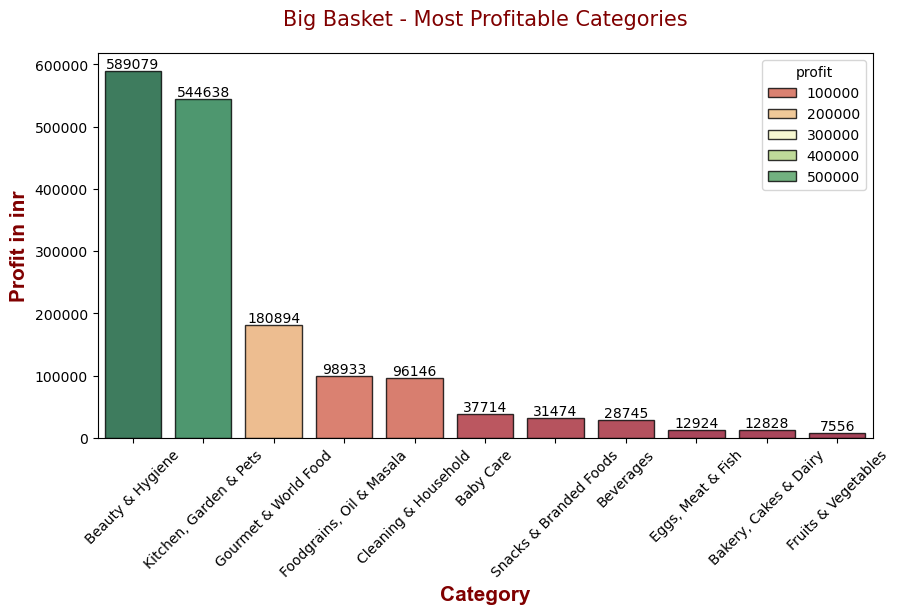

In [49]:
# Plotting Categories by Profit.

fig, ax1 = plt.subplots( figsize = (10,5) )

ax1 = sns.barplot(data = df_category_profit , x = 'category', y = 'profit', errorbar = None, 
            hue = 'profit', palette = 'RdYlGn', alpha = 0.8, edgecolor = 'black')

for i in range(len(df_category_profit)):
    ax1.text(df_category_profit['category'][i], df_category_profit['profit'][i], df_category_profit['profit'][i],
            va = 'bottom', ha = 'center')


ax1.set_title("Big Basket - Most Profitable Categories", fontsize = 15, color ='maroon', y = 1.05)

ax1.set_xlabel('Category', fontsize = 15, color = 'maroon', fontweight = 'bold', font = 'Arial')
ax1.set_ylabel('Profit in inr', fontsize = 15, color = 'maroon', fontweight = 'bold', font = 'Arial')

plt.xticks(rotation = 45)

plt.show()



In [50]:
# Top 15 categories - DATA TABLE

category_top_10 = df.groupby('category', as_index = False)['profit'].sum().sort_values(['profit'], ascending = False).nlargest(10, 'profit').reset_index().drop(columns = 'index')



In [51]:
category_top_10

,category,profit
0,Beauty & Hygiene,589079
1,"Kitchen, Garden & Pets",544638
2,Gourmet & World Food,180894
3,"Foodgrains, Oil & Masala",98933
4,Cleaning & Household,96146
5,Baby Care,37714
6,Snacks & Branded Foods,31474
7,Beverages,28745
8,"Eggs, Meat & Fish",12924
9,"Bakery, Cakes & Dairy",12828


### 4.2 Most Profitable Brands

In [52]:
brand_top_15 = df.groupby('brand', as_index = False)['profit'].sum().sort_values('profit',ascending = False).nlargest(15, 'profit').reset_index().drop(columns = 'index')


In [53]:
brand_top_15

,brand,profit
0,BB Home,59276
1,bb Royal,45054
2,DP,35567
3,Prestige,34045
4,BORGES,32020
5,Ajmal,25896
6,bb Combo,25349
7,INATUR,24199
8,Nova,22705
9,Frestol,21200


In [54]:
# Clean the brand names to look uniform

# How:
# 1. If there are multiple words and the first is 2 letters long then the first should be in UPPERCASE and rest in first letter cap case.
# 2. If there is only one word in brand and it is 2 letters long then give UPPERCASE else first letter cap.

# This logic works for the top 15 shown above. Needs tweeks case by case.


def change_case(x):
    lst = x.split()
    
    if len(lst) > 1:
        if len(lst[0]) == 2:
            return lst[0].upper() +  ' ' + lst[1].title()
        else:
            return x.title()
    else:
        if len(x) == 2:
            return lst[0].upper()
        return lst[0].title()


brand_top_15['brand'] = brand_top_15['brand'].apply(change_case)


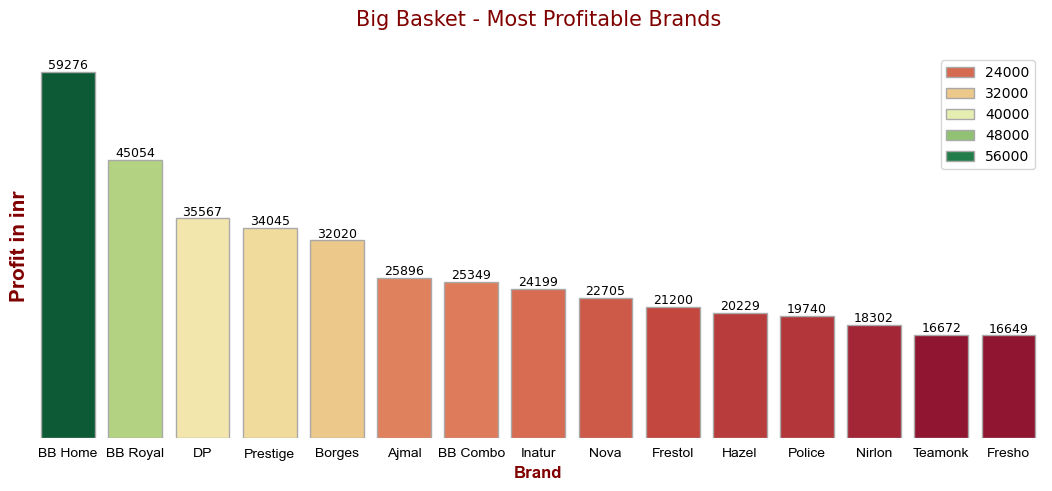

In [55]:
fig, ax = plt.subplots( figsize = (13,5))

ax1 = sns.barplot(data = brand_top_15, x = 'brand', y = 'profit', hue = 'profit', palette = 'RdYlGn', edgecolor = 'darkgrey')



# set data labels
for i in range(len(brand_top_15)):
    ax1.text(brand_top_15['brand'][i], brand_top_15['profit'][i], brand_top_15['profit'][i],
            va = 'bottom', ha = 'center', fontsize = 9)


ax1.set_title("Big Basket - Most Profitable Brands", fontsize = 15, color ='maroon', y = 1.05)

# axis labels
ax.set_xlabel('Brand', fontsize = 12, color = 'maroon', fontweight = 'bold', font = 'Arial')
ax.set_ylabel('Profit in inr', fontsize = 15, color = 'maroon', fontweight = 'bold', font = 'Arial')

# remove tick marks on x y axes
plt.tick_params( bottom = False, labelbottom = True)
plt.xticks(fontsize = 9, font = 'Arial')
plt.yticks([])

# move legend outside
plt.legend(bbox_to_anchor= (1,1), loc = 1)

# remove plot border
ax1.spines[:].set_visible(False)

plt.show()

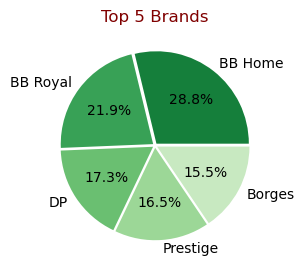

In [56]:
# Top 5 brands
brand_top_15
brand_top_5 = brand_top_15.nlargest(5, 'profit')
brand_top_15['brand'] = brand_top_15['brand'].apply(change_case)

plt.figure(figsize = (5,3))

brand_color = plt.cm.Greens_r(np.linspace(0.2,0.75,5))
hatch_pattern = ['/','\\','-','+','o']
explode_ratio = [0.0125,0.0125,0.0125,0.0125,0.0125]
explode_ratio1 = [0.025,0.025,0.025,0.025,0.025]

ax1 = plt.pie(brand_top_5['profit'], labels = brand_top_5['brand'], 
              counterclock = True, colors = brand_color, autopct = '%1.1f%%', explode = explode_ratio1)


plt.title('Top 5 Brands', color = 'maroon')
plt.show()


### 4.3 Most Rated Brands

In [57]:

# aggregate by brand and find mean of rating 
df_brand_rating = df.groupby('brand').agg( mean_rating = ('rating','mean'), pdts = ('brand','count'), sum_profit = ('profit','sum') )


# only including brands where pdt offerings are above 100. Otherwise a brand with 1 pdt and 5 rating will rank first. 
brand_top_10_highly_rated = df_brand_rating.query("pdts >= 100").nlargest(10,'mean_rating').reset_index()

# cleaning brand
brand_top_10_highly_rated['brand'] = brand_top_10_highly_rated['brand'].apply(change_case)

# rounding rating
brand_top_10_highly_rated['mean_rating'] = brand_top_10_highly_rated['mean_rating'].round(2)




In [58]:
brand_top_10_highly_rated

,brand,mean_rating,pdts,sum_profit
0,Fresho Signature,4.21,171,7815
1,DP,4.20,250,35567
2,Britannia,4.19,104,707
3,Himalaya,4.14,141,4113
4,Colgate,4.14,107,4207
5,Loreal Paris,4.12,104,5810
6,Dabur,4.11,138,4077
7,BB Home,4.11,428,59276
8,Keya,4.10,101,2368
9,Mtr,4.07,100,787


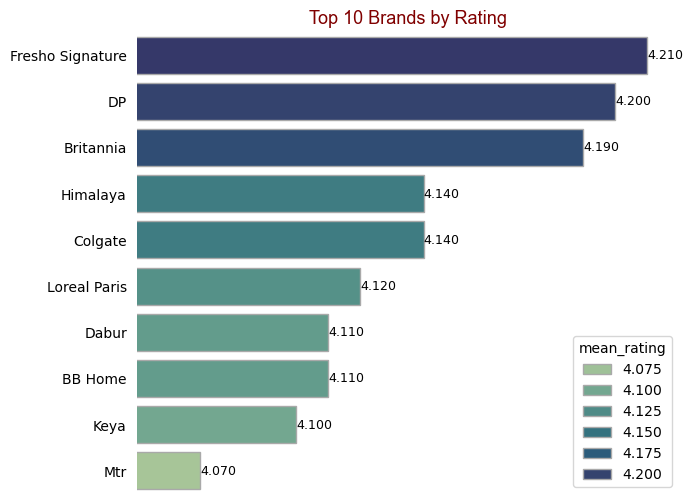

In [59]:
## Top 10 brands by rating 

fig, ax = plt.subplots( figsize = (7,6))

ax = sns.barplot(data = brand_top_10_highly_rated, y = 'brand', x = 'mean_rating', errorbar = None, hue = 'mean_rating', 
                 palette = 'crest', edgecolor = 'darkgrey')

# datalabels

for i in range(0,10):
    ax.text(brand_top_10_highly_rated['mean_rating'][i], #x coord
            brand_top_10_highly_rated['brand'][i], # y coord
            f"{brand_top_10_highly_rated['mean_rating'][i]:.3f}", # data values
            va = 'center', ha = 'left', fontsize = 9)


sns.despine( right = True, bottom = True, top = True, left = True)

plt.tick_params(bottom = False, left = False, labelbottom = False)

ax.set_title('Top 10 Brands by Rating', font = 'Arial', fontsize = 13, color = 'maroon')
ax.set_xlabel('')
ax.set_ylabel('')

ax.set_xlim(4.05, 4.22)

plt.show()
    

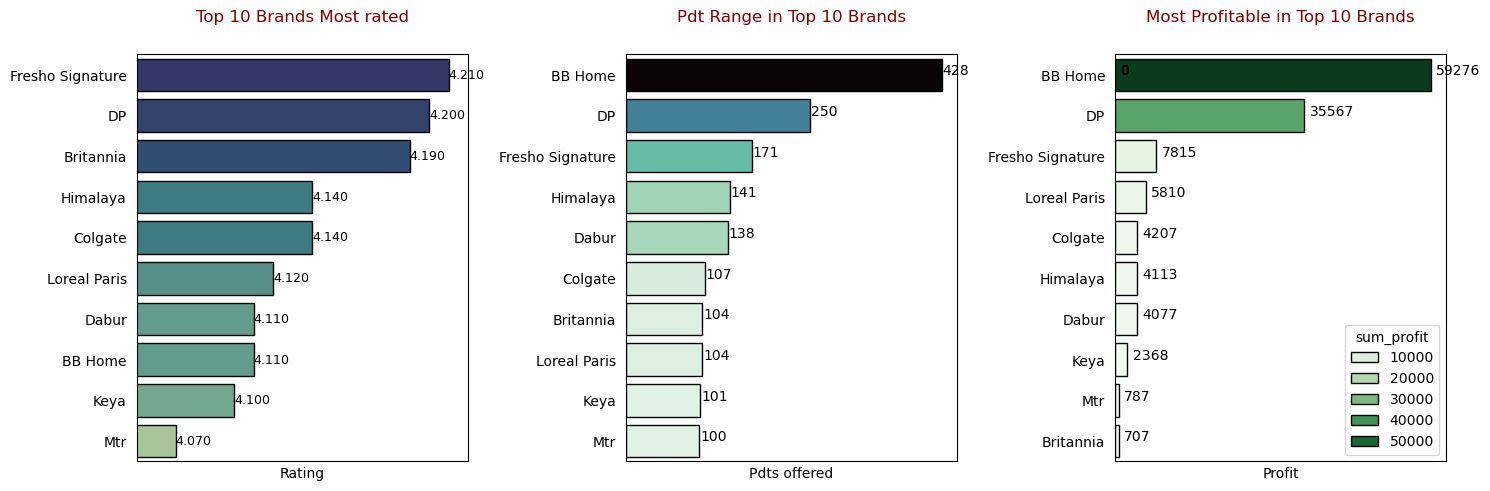

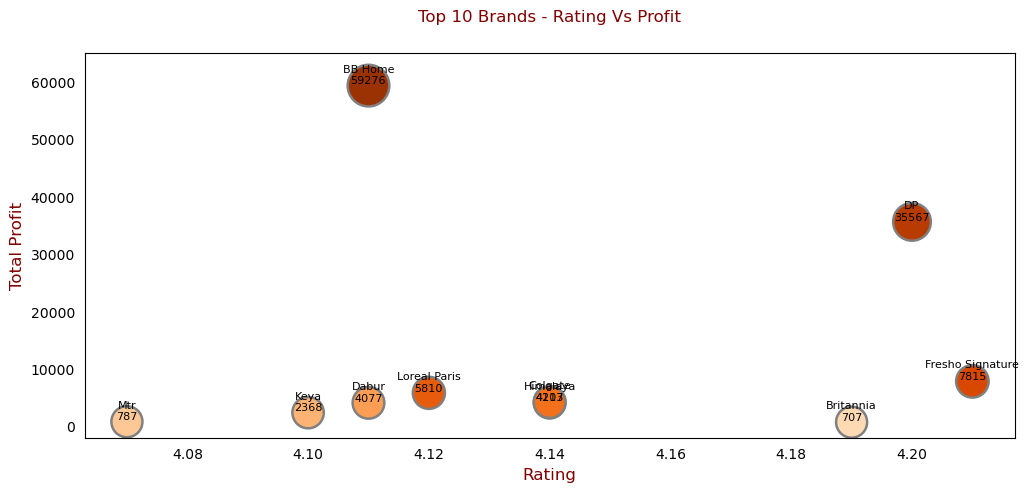

In [188]:
## Plotting Rating,  No. of Pdts offered for Top 10 Brands by rating

fig1 , (ax1, ax2, ax3 ) = plt.subplots( 1,3, figsize = (15,5), tight_layout = True )
fig2 , ax4 = plt.subplots(1,1, figsize = (12,5))

scatter_color = plt.cm.Oranges(list(np.linspace(0.2, 0.91, 10)))

ax1 = sns.barplot(data = brand_top_10_highly_rated, y = 'brand', x = 'mean_rating', errorbar = None, hue = 'mean_rating', 
                 palette = 'crest', edgecolor = 'black',legend = False, ax = ax1)

ax2 = sns.barplot(data = brand_top_10_highly_rated.sort_values('pdts', ascending = False), y = 'brand', x = 'pdts', errorbar = None, hue = 'pdts', 
                 palette = 'mako_r', edgecolor = 'black',legend = False, ax = ax2)

ax3 = sns.barplot(data = brand_top_10_highly_rated.sort_values('sum_profit', ascending = False), x = 'sum_profit', y = 'brand', 
                  hue = 'sum_profit', palette = 'Greens', edgecolor = 'black', ax = ax3)

ax4 = sns.scatterplot(data = brand_top_10_highly_rated, x = 'mean_rating', y = 'sum_profit', size = 'sum_profit', sizes = (500,900), 
                      hue = 'sum_profit', palette = scatter_color, edgecolor = 'grey', legend = False, ax = ax4)


## Data Labels

for i in range(0,10):
    ax1.text(brand_top_10_highly_rated['mean_rating'][i], #x coord
            brand_top_10_highly_rated['brand'][i], # y coord
            f"{brand_top_10_highly_rated['mean_rating'][i]:.3f}", # data values
            va = 'center', ha = 'left', fontsize = 9)

for i in ax2.patches:
    ax2.text(i.get_width()+1, i.get_y()+i.get_height()/2, f'{i.get_width():.0f}')

for i in ax3.patches:
    ax3.text(i.get_width()+1000, i.get_y()+i.get_height()/2, f'{i.get_width():.0f}')

for i in range(0,10):
    ax4.text(brand_top_10_highly_rated['mean_rating'][i], brand_top_10_highly_rated['sum_profit'][i], 
             f"{brand_top_10_highly_rated['brand'][i]}\n{brand_top_10_highly_rated['sum_profit'][i]}",
            va = 'bottom', ha = 'center', fontsize = 8) 


ax1.set_xlabel('Rating')
ax1.set_ylabel('')
ax1.tick_params(axis = 'x', bottom = False, labelbottom = False)
ax1.tick_params(axis = 'y', left = False)
ax1.set_title("Top 10 Brands Most rated", fontsize = 12, color ='maroon',y = 1.06)
ax1.set_xlim(4.05, 4.22)

ax2.set_xlabel('Pdts offered')
ax2.set_ylabel('')
ax2.tick_params(axis = 'x', bottom = False, labelbottom = False)
ax2.tick_params(axis = 'y', left = False)
ax2.set_title('Pdt Range in Top 10 Brands', fontsize = 12, color ='maroon',y = 1.06)
#ax1.set_xlim(4.05, 4.22)

ax3.set_xlabel('Profit')
ax3.set_ylabel('')
ax3.tick_params(axis = 'x', bottom = False, labelbottom = False)
ax3.tick_params(axis = 'y', left = False)
ax3.set_title('Most Profitable in Top 10 Brands', fontsize = 12, color ='maroon',y = 1.06)


ax4.set_xlabel('Rating',fontsize = 12, color ='maroon')
ax4.set_ylabel('Total Profit',fontsize = 12, color ='maroon')
ax4.tick_params(axis = 'x', bottom = False, labelbottom = True)
ax4.tick_params(axis = 'y', left = False)
ax4.set_title('Top 10 Brands - Rating Vs Profit', fontsize = 12, color ='maroon',y = 1.06)
ax4.set_ylim(-2000,65000)

plt.show()

##### Observations:
1. The brand with Highest ratings is Fresho Signature, but its not making the most profit.
2. The brand making most profits is BB Home - Big Basket's home label, but its not the best rated. It's 8th on the list
3. Himalaya and Dabur make the cut, but shoppers prefer online-exclusive labels over traditional brands.


## 5. Deep-Dive Analysis

### 5.1 Product Segmentation by price

In [67]:
#### Creating Product segments based on sale_price column

df['sale_price_categories'] = pd.cut(df['sale_price'], 
                                     bins = [0,100,200,400,1000,5000,15000], labels = ['Value','Budge','Midrange','Premium','Luxury','Elite'])

In [68]:
# No. of Pdts in each Segment

df.groupby('sale_price_categories', observed = True)['product'].count().reset_index()


,sale_price_categories,product
0,Value,7752
1,Budge,6857
2,Midrange,7123
3,Premium,4466
4,Luxury,1310
5,Elite,46


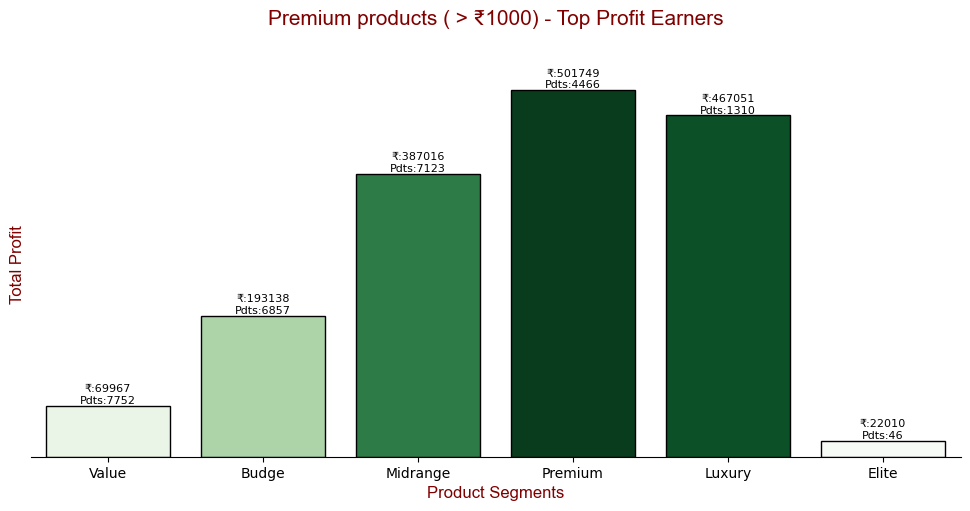

In [69]:
# Visualize Profits for each Product Segment

plt.figure( figsize = (12,5))

df_cat_profit = df.groupby('sale_price_categories', observed = True).agg(profit = ('profit','sum'), 
                                                                         count_pdts = ('profit','count'),
                                                                         subcategories = ('sub_category','nunique')
                                                                        ).reset_index()

ax1 = sns.barplot(data = df_cat_profit,x = 'sale_price_categories', y = 'profit',
                  legend = False, hue = 'profit',palette = 'Greens', errorbar = None, edgecolor = 'black')


for i in range(len(df_cat_profit)):
    ax1.text(df_cat_profit['sale_price_categories'][i], df_cat_profit['profit'][i], 
             f"\u20B9:{df_cat_profit['profit'][i]}\nPdts:{df_cat_profit['count_pdts'][i]}",
            va = 'bottom', ha = 'center', fontsize = 8) 

plt.title('Premium products ( > \u20B91000) - Top Profit Earners', font = 'Arial', fontsize = 15, color = 'maroon', y = 1.1)


ax1.set_xlabel('Product Segments',font = 'Arial', fontsize = 12, color = 'maroon')
ax1.set_ylabel('Total Profit',font = 'Arial', fontsize = 12, color = 'maroon')

sns.despine(offset = 0)

ax1.spines['left'].set_visible(False)
ax1.tick_params(axis = 'y', left = False, labelleft = False)

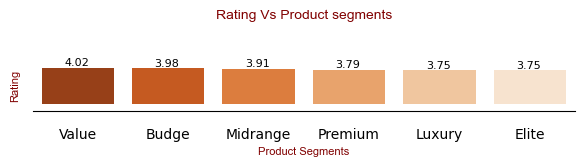

In [70]:
# Visualize Rating for each Product Segment 

plt.figure( figsize = (7,0.5))

ax1 = sns.barplot(data = df, x = 'sale_price_categories', y = 'rating', estimator = 'mean',
                  legend = False, hue = 'sale_price_categories', palette = 'Oranges_r', errorbar = None) #, edgecolor = 'black')

for i in ax1.patches:
    ax1.text(i.get_x()+0.25, i.get_height()+0.2, round(i.get_height(),2), fontsize = 8)


plt.title('Rating Vs Product segments', font = 'Arial', fontsize = 10, color = 'maroon', y = 2)

ax1.set_xlabel('Product Segments',font = 'Arial', fontsize = 8, color = 'maroon')
ax1.set_ylabel('Rating',font = 'Arial', fontsize = 8, color = 'maroon')

sns.despine(offset = 5)

ax1.spines['left'].set_visible(False)
ax1.tick_params(axis = 'y', left = False, labelleft = False)
ax1.tick_params(axis = 'x', bottom = False, size = 8)

In [71]:
df_agg = df.groupby('sale_price_categories',observed = True).agg(count = ('product','count'), 
                                                                 mean_rating = ('rating','mean'), 
                                                                 profit_sum=('profit','sum')
                                                                ).reset_index()

In [194]:
df_agg

,sale_price_categories,count,mean_rating,profit_sum
0,Value,7752,4.023463,69967
1,Budge,6857,3.979907,193138
2,Midrange,7123,3.910121,387016
3,Premium,4466,3.785439,501749
4,Luxury,1310,3.750886,467051
5,Elite,46,3.750000,22010


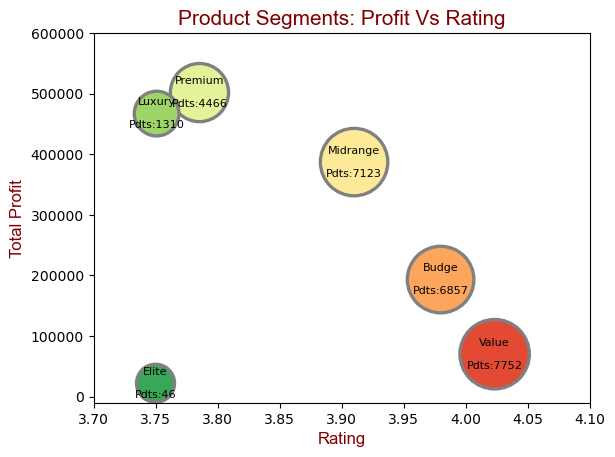

In [168]:
## Visualizing 3 metrics - Profit, Rating and No. of Pdts - For each Product Category

ax1 = sns.scatterplot(data = df_agg, x = 'mean_rating', y = 'profit_sum', size = 'count', sizes = (750,2500),
                      hue = 'sale_price_categories', palette = 'RdYlGn', edgecolor = 'grey', legend = False)


for i in range(len(df_agg)):
    ax1.text(df_agg['mean_rating'][i], df_agg['profit_sum'][i], 
             f"{df_agg['sale_price_categories'][i]}\n\nPdts:{df_agg['count'][i]}",
            va = 'center', ha = 'center', fontsize = 8) 

ax1.set_ylim(-10000, 600000)
ax1.set_xlim(3.7, 4.1)

ax1.set_title('Product Segments: Profit Vs Rating', font = 'Arial', fontsize = 15, color = 'maroon')

ax1.set_ylabel('Total Profit',font = 'Arial', fontsize = 12, color = 'maroon')
ax1.set_xlabel('Rating',font = 'Arial', fontsize = 12, color = 'maroon')

plt.show()

##### Observations

From Profit vs Pdt Segment
1. Premium and Luxury segments contribute the most profit (5lakhs )
2. Elite has very few products but still brings profit
3. Value and Budget products are high in count but generate the least total profit.

From Rating vs Pdt Segment
1. Ratings decrease with increase in price
2. Value and budget have better ratings ~ 4
3. Luxury and Elite have slightly less ~3.75

From Profit Vs Rating 
1. Premium - high profit / low rating => High margin but not most loved
2. Budget - low profit / high rating => Loved by users, not very profitable
3. Elite - very low profit / avg rating => Niche pdts, higher price, fewer sales.




### 5.2 Categories that consistently offer high customer satisfaction



##### Consistently high customer satisfaction

1. High mean rating 
2. Low standard deviation of ratings
3. Number of products in the category 


In [109]:
# Finding category wise ratings - avg, std & cnt

ratings_summary = df.groupby('category',observed = True).agg(mean_rating = ('rating','mean'),
                                                          std_rating = ('rating','std'),
                                                          count_pdts = ('product','count'),
                                                            subcategories = ('sub_category','nunique')).reset_index()

In [110]:
ratings_summary['std_rating'] = round(ratings_summary['std_rating'],2)
ratings_summary['mean_rating'] = round(ratings_summary['mean_rating'],2)

In [111]:
ratings_summary = ratings_summary.dropna(axis = 0)

In [112]:
ratings_summary

,category,mean_rating,std_rating,count_pdts,subcategories
0,Baby Care,4.02,0.76,610,7
1,"Bakery, Cakes & Dairy",3.91,0.50,851,8
2,Beauty & Hygiene,3.93,0.86,7867,10
3,Beverages,4.08,0.62,885,6
4,Cleaning & Household,3.96,0.66,2674,10
6,"Foodgrains, Oil & Masala",4.06,0.44,2676,9
8,Gourmet & World Food,3.98,0.81,4690,14
9,"Kitchen, Garden & Pets",3.73,0.84,3580,10
10,Snacks & Branded Foods,3.98,0.55,2814,12


In [113]:
ratings_summary = ratings_summary.sort_values(by = ['mean_rating', 'std_rating', 'count_pdts'], 
                            ascending = [False, True, False]).reset_index()

In [114]:
ratings_summary = ratings_summary.drop(columns = 'index')

In [115]:
ratings_summary

,category,mean_rating,std_rating,count_pdts,subcategories
0,Beverages,4.08,0.62,885,6
1,"Foodgrains, Oil & Masala",4.06,0.44,2676,9
2,Baby Care,4.02,0.76,610,7
3,Snacks & Branded Foods,3.98,0.55,2814,12
4,Gourmet & World Food,3.98,0.81,4690,14
5,Cleaning & Household,3.96,0.66,2674,10
6,Beauty & Hygiene,3.93,0.86,7867,10
7,"Bakery, Cakes & Dairy",3.91,0.50,851,8
8,"Kitchen, Garden & Pets",3.73,0.84,3580,10


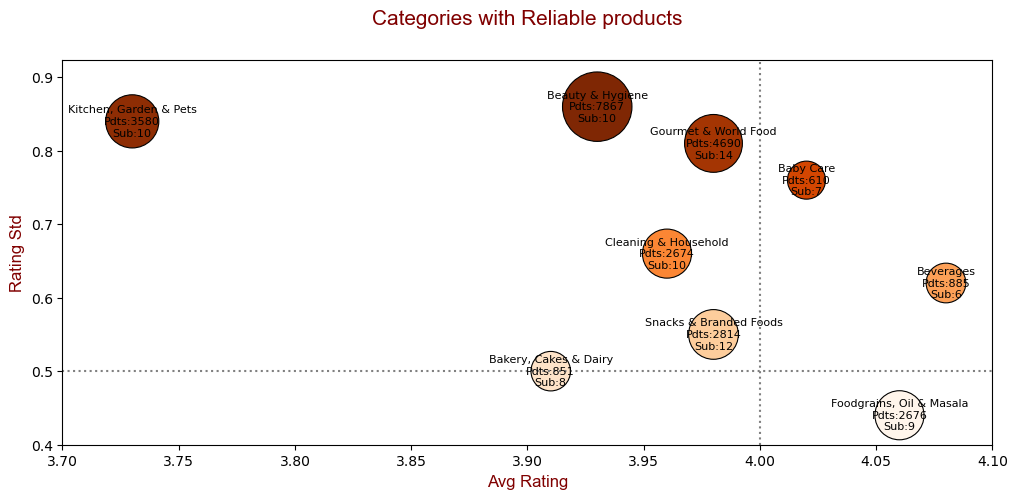

In [117]:
## Plotting RATING avg Vs RATING std deviation For Categories

fig, ax1 = plt.subplots( figsize = (12,5))

ax1 = sns.scatterplot(data = ratings_summary, x = 'mean_rating', y = 'std_rating', size = 'count_pdts', sizes = (750,2500),
                      hue = 'std_rating', palette = 'Oranges', edgecolor = 'black', legend = False, linewidth = 0.8,
                     marker = 'o')


for i in range(len(ratings_summary)):
    ax1.text(ratings_summary['mean_rating'][i], ratings_summary['std_rating'][i], 
             f"{ratings_summary['category'][i]}\nPdts:{ratings_summary['count_pdts'][i]}\nSub:{ratings_summary['subcategories'][i]}",
            va = 'center', ha = 'center', fontsize = 8) 

ax1.set_ylim(0.4, 0.924)
ax1.set_xlim(3.7, 4.1)


plt.axvline(x=4, linestyle= 'dotted', color='grey')   # high rating line
plt.axhline(y=0.5, linestyle='dotted', color='grey')   # low std line


#ax1.set_title('Categories with Reliable products', font = 'Arial', fontsize = 15, color = 'maroon')
plt.title('Categories with Reliable products', font = 'Arial', fontsize = 15, color = 'maroon', y = 1.07)

ax1.set_ylabel('Rating Std',font = 'Arial', fontsize = 12, color = 'maroon')
ax1.set_xlabel('Avg Rating',font = 'Arial', fontsize = 12, color = 'maroon')

plt.show()


In [132]:
# Top 5 - Most consistent CATEGORIES:

ratings_summary.sort_values(['mean_rating','std_rating'], 
                            ascending = [True, False]).nlargest(5,['mean_rating','std_rating'])[['category','mean_rating','std_rating','count_pdts','subcategories']].reset_index().drop(columns = 'index')



,category,mean_rating,std_rating,count_pdts,subcategories
0,Beverages,4.08,0.62,885,6
1,"Foodgrains, Oil & Masala",4.06,0.44,2676,9
2,Baby Care,4.02,0.76,610,7
3,Gourmet & World Food,3.98,0.81,4690,14
4,Snacks & Branded Foods,3.98,0.55,2814,12


In [120]:
# Bottom 5 - Least consistent CATEGORIES:

ratings_summary.sort_values(['mean_rating','std_rating'], 
                            ascending = [False, True]).nsmallest(5,['mean_rating','std_rating'])[['category','mean_rating','std_rating','count_pdts','subcategories']].reset_index().drop(columns = 'index')



,category,mean_rating,std_rating,count_pdts,subcategories
0,"Kitchen, Garden & Pets",3.73,0.84,3580,10
1,"Bakery, Cakes & Dairy",3.91,0.50,851,8
2,Beauty & Hygiene,3.93,0.86,7867,10
3,Cleaning & Household,3.96,0.66,2674,10
4,Snacks & Branded Foods,3.98,0.55,2814,12


#### 4.2 b. Sub-Categories with Consistently High Satisfaction 

In [122]:

# Finding sub-category wise ratings - avg, std & cnt

ratings_summary_subcat = df.groupby(['category','sub_category'],observed = True).agg(mean_rating = ('rating','mean'),
                                                          std_rating = ('rating','std'),
                                                          count_pdts = ('product','count')).reset_index()

In [123]:
# Only considering sub-cats with pdts more than 30 listed
ratings_summary_subcat = ratings_summary_subcat[ratings_summary_subcat['count_pdts']>30]

In [124]:
ratings_summary_subcat = ratings_summary_subcat.dropna(axis = 0)
ratings_summary_subcat['mean_rating'] = round(ratings_summary_subcat['mean_rating'],2)
ratings_summary_subcat['std_rating'] = round(ratings_summary_subcat['std_rating'],2)

In [125]:
pd.set_option('display.max_rows', 500)

In [126]:
ratings_summary_subcat.sort_values(by = ['mean_rating', 'std_rating', 'count_pdts'], ascending = [False, True, False])

,category,sub_category,mean_rating,std_rating,count_pdts
34,Cleaning & Household,Detergents & Dishwash,4.26,0.42,261
71,Gourmet & World Food,Oils & Vinegar,4.21,0.79,239
3,Baby Care,Baby Food & Formula,4.18,0.38,47
26,Beverages,Energy & Soft Drinks,4.18,0.49,111
88,Snacks & Branded Foods,Biscuits & Cookies,4.17,0.31,305
51,"Foodgrains, Oil & Masala",Edible Oils & Ghee,4.15,0.34,248
28,Beverages,"Health Drink, Supplement",4.14,0.47,100
84,"Kitchen, Garden & Pets",Pet Food & Accessories,4.14,0.60,356
94,Snacks & Branded Foods,"Noodle, Pasta, Vermicelli",4.13,0.33,122
55,"Foodgrains, Oil & Masala","Salt, Sugar & Jaggery",4.12,0.39,137


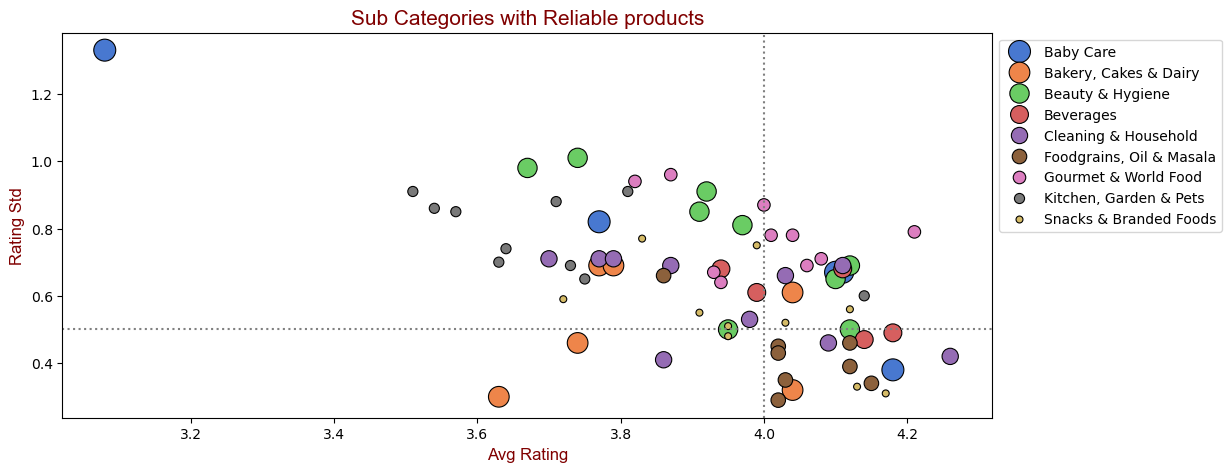

In [127]:
## Plotting RATING avg Vs RATING std deviation For Sub-Categories

fig, ax1 = plt.subplots( figsize = (12,5))

ax1 = sns.scatterplot(data = ratings_summary_subcat, x = 'mean_rating', y = 'std_rating', size = 'category', sizes = (25,250),
                      hue = 'category', palette = 'muted', edgecolor = 'black', legend = True, linewidth = 0.8,
                     marker = 'o')


plt.axvline(x=4, linestyle= 'dotted', color='grey')   # high rating line
plt.axhline(y=0.5, linestyle='dotted', color='grey')   # low std line

ax1.set_title('Sub Categories with Reliable products', font = 'Arial', fontsize = 15, color = 'maroon')

ax1.set_ylabel('Rating Std',font = 'Arial', fontsize = 12, color = 'maroon')
ax1.set_xlabel('Avg Rating',font = 'Arial', fontsize = 12, color = 'maroon')

plt.legend(bbox_to_anchor= (1,1), loc = 2)

plt.show()


In [128]:
# Top 10 most consistent sub-categories

ratings_summary_subcat[(ratings_summary_subcat['mean_rating']>4) & (ratings_summary_subcat['std_rating']<=0.5)].sort_values(
    ['mean_rating','std_rating'], ascending = [False, True]
).nlargest(10,'mean_rating')[['sub_category','mean_rating','std_rating','count_pdts']].reset_index().drop(columns = 'index')

,sub_category,mean_rating,std_rating,count_pdts
0,Detergents & Dishwash,4.26,0.42,261
1,Baby Food & Formula,4.18,0.38,47
2,Energy & Soft Drinks,4.18,0.49,111
3,Biscuits & Cookies,4.17,0.31,305
4,Edible Oils & Ghee,4.15,0.34,248
5,"Health Drink, Supplement",4.14,0.47,100
6,"Noodle, Pasta, Vermicelli",4.13,0.33,122
7,"Salt, Sugar & Jaggery",4.12,0.39,137
8,Masalas & Spices,4.12,0.46,889
9,Oral Care,4.12,0.50,271


##### Observations:

Categories: Top 3
1. Foodgrains, oil, masala - avg rating - 4.06, low Std, good volumne
2. Beverages - avg rating - 4.08, slightly higher variation
3. Snacks and branded foods - Reliable with avg rating 3.98


Sub Categories: Top 5
1. Detergents & Dishwash
2. Biscuits & cookies
3. Edible oils & Ghee
4. Noode, Pasta, Vermicelli
5. Salt, Sugar & Jaggery

### 5.3 High Profit & Low Rating Products

In [137]:
# What is high profit? what is low rating? - They could be overpriced. 

# High profit = pdts in the top 20% of 'profit'
high_profit_mark = df_subset['profit'].quantile(0.8)

# Low rating = pdts in the rating below 3.5

In [133]:
# Filtering only the needed cols
df_subset = df.copy()
df_subset = df_subset[['product','category','sub_category','sale_price','rating','profit']]

In [134]:
df_subset.dropna(axis = 0, inplace = True)

In [138]:
df_low_rating_high_profit = df_subset[(df_subset['profit'] >= high_profit_mark) & (round(df_subset['rating'],1) <= 3.5 )]

In [139]:
df_low_rating_high_profit.sort_values(['rating'])

,product,category,sub_category,sale_price,rating,profit
9979,Dionysus Eau De Toilette For Men,Beauty & Hygiene,Fragrances & Deos,419,1.0,180
21715,"Tiffin - Stylo Hot Executive, Blue","Kitchen, Garden & Pets",Storage & Accessories,449,1.0,124
7290,Melamine Condiment With Spoon - Red,"Kitchen, Garden & Pets",Crockery & Cutlery,229,1.0,66
21557,Shot Glass - Plaza Shot,"Kitchen, Garden & Pets",Crockery & Cutlery,739,1.0,395
3087,Gardenia Essential Oil,Beauty & Hygiene,Skin Care,312,1.0,98
...,...,...,...,...,...,...
15330,Director Coffee Mugs - Hilton 392,"Kitchen, Garden & Pets",Crockery & Cutlery,459,3.5,150
15289,Reusable Anti Pollution Face Mask - With Activ...,Beauty & Hygiene,Health & Medicine,276,3.5,73
6865,"2 Fold Umbrella - Auto-Open & Manual Close, Sk...","Kitchen, Garden & Pets",Storage & Accessories,269,3.5,280
22942,Woman - Green Eau De Toilette Deodorant,Beauty & Hygiene,Men's Grooming,195,3.5,84


In [143]:
# Top 3 Categories with overpriced products 

df_low_rating_high_profit.groupby('category').count().sort_values('product', ascending = False)[['product']].nlargest(3,'product')

,product
category,
"Kitchen, Garden & Pets",540
Beauty & Hygiene,381
Cleaning & Household,92


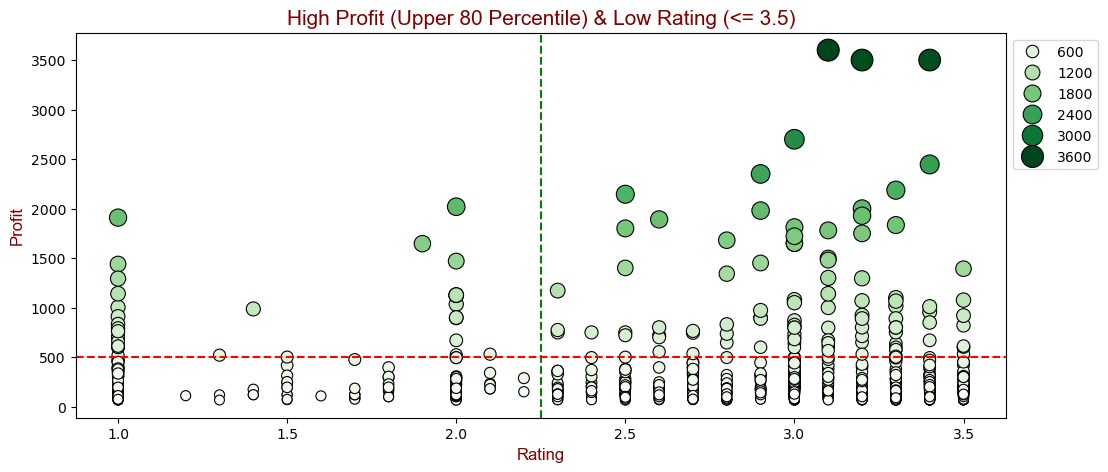

In [144]:
# Ploting pdts that are high in profit low in rating 

fig, ax1 = plt.subplots( figsize = (12,5))

ax1 = sns.scatterplot(data = df_low_rating_high_profit, x = 'rating', y = 'profit', size = 'profit', sizes = (50,250),
                      hue = 'profit', palette = 'Greens', edgecolor = 'black', legend = True, linewidth = 0.8,
                     marker = 'o')


plt.axvline(x=2.25, linestyle='--', color='green')   # lowest rating line
plt.axhline(y=500, linestyle='--', color='red')      # high profit line


ax1.set_title('High Profit (Upper 80 Percentile) & Low Rating (<= 3.5)', font = 'Arial', fontsize = 15, color = 'maroon')

ax1.set_ylabel('Profit',font = 'Arial', fontsize = 12, color = 'maroon')
ax1.set_xlabel('Rating',font = 'Arial', fontsize = 12, color = 'maroon')

plt.legend(bbox_to_anchor= (1,1), loc = 2)

plt.show()

##### Top 3 High-profit & low-rating Categories:
1. Kitchen, Garden & Pets
2. Beauty & Hygiene
3. Cleaning & Household


In [146]:
# Only Isolate pdts in the top left quadrant
# with Rating <= 2 and profit >= 500
df_low_rating_high_profit_summary = df_low_rating_high_profit[(df_low_rating_high_profit['profit'] >= 500 ) 
& (df_low_rating_high_profit['rating'] <= 2.000)][['category','sub_category','product','profit','rating']].sort_values(['profit','rating'], ascending = [False, True]).reset_index().drop(columns = 'index')

In [147]:
df_low_rating_high_profit_summary.groupby('sub_category', observed = True).count().sort_values('product', ascending = False)[['product']]

,product
sub_category,
Fragrances & Deos,15
Steel Utensils,6
Men's Grooming,3
Cookware & Non Stick,2
Hair Care,2
Kitchen Accessories,2
Bath & Hand Wash,1
Crockery & Cutlery,1
Health & Medicine,1


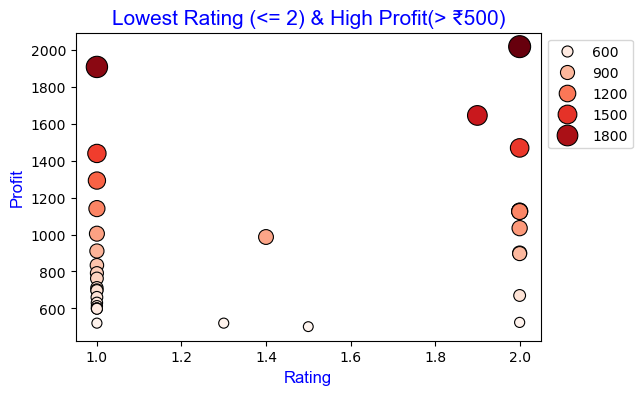

In [148]:
# Visualize Q1 Lowest Rating < 2 and High profit > 500

fig, ax1 = plt.subplots( figsize = (6,4))

ax1 = sns.scatterplot(data = df_low_rating_high_profit_summary, x = 'rating', y = 'profit', size = 'profit', sizes = (50,250),
                      hue = 'profit', palette = 'Reds', edgecolor = 'black', legend = True, linewidth = 0.8,
                     marker = 'o')

ax1.set_title('Lowest Rating (<= 2) & High Profit(> \u20B9500)', font = 'Arial', fontsize = 15, color = 'blue')

ax1.set_ylabel('Profit',font = 'Arial', fontsize = 12, color = 'blue')
ax1.set_xlabel('Rating',font = 'Arial', fontsize = 12, color = 'blue')

plt.legend(bbox_to_anchor= (1,1), loc = 2)

plt.show()

##### Observations:

1. There are 1k products that have rating <= 3.5 & profit in the upper 80 quantile
2. Of this 32 pdts have rating as low as 2 and profits greater than 500
3. This occurs mostly in the **Kitchen, Garden & Pets category & Beauty & Hygiene** Category
4. The most overpriced and downrated subcategories are **Fragrances & Deodrants, Steel utensils**

### 5.4 Categories and their Price Ranges


In [149]:
#1. Binning sale_price

bins_hm = [0, 100, 250, 500, 1000, 2000, float('inf')]
labels_hm = ['0-100', '100-250', '250-500', '500-1000', '1000-2000', '2000+']
df['price_range'] = pd.cut(df['sale_price'], bins=bins_hm, labels=labels_hm)


In [150]:
# 2. How many pdts fall into each price range for each category?
df_hm = df.groupby(['category','price_range'], observed = True)['product'].count().unstack(fill_value = 0)

In [151]:
df_hm

price_range,0-100,100-250,250-500,500-1000,1000-2000,2000+
category,,,,,,
Baby Care,60,170,163,131,65,21
"Bakery, Cakes & Dairy",403,321,111,15,1,0
Beauty & Hygiene,1338,2746,2119,1046,440,178
Beverages,243,348,219,62,11,2
Cleaning & Household,890,1006,566,160,45,7
"Eggs, Meat & Fish",44,157,105,38,5,1
"Foodgrains, Oil & Masala",1342,796,317,163,48,10
Fruits & Vegetables,492,57,7,1,0,0
Gourmet & World Food,894,1661,1510,484,101,40


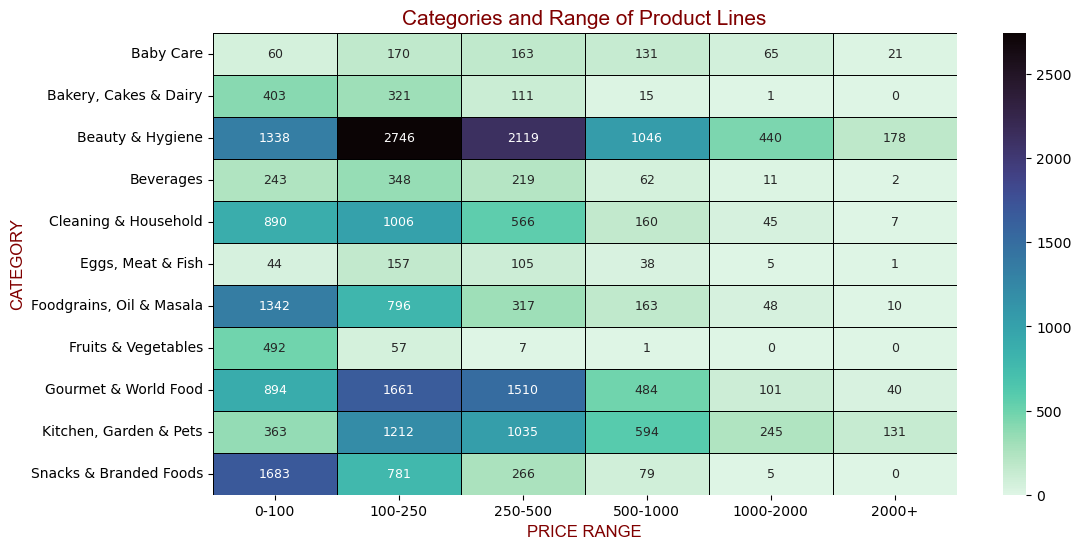

In [152]:
plt.figure(figsize = (12,6))

ax1 = sns.heatmap(df_hm, annot = True, fmt = 'd', cmap = 'mako_r', linewidths = 0.5,  annot_kws={'size':9}, linecolor = 'black')

ax1.set_xlabel('PRICE RANGE',font = 'Arial', fontsize = 12, color = 'maroon')
ax1.set_ylabel('CATEGORY',font = 'Arial', fontsize = 12, color = 'maroon')
ax1.set_title('Categories and Range of Product Lines',font = 'Arial', fontsize = 15, color = 'maroon')

plt.show()

In [153]:
heatmap_norm = df_hm.div(df_hm.sum(axis=1), axis=0)

In [154]:
heatmap_norm

price_range,0-100,100-250,250-500,500-1000,1000-2000,2000+
category,,,,,,
Baby Care,0.098361,0.278689,0.267213,0.214754,0.106557,0.034426
"Bakery, Cakes & Dairy",0.473561,0.377203,0.130435,0.017626,0.001175,0.000000
Beauty & Hygiene,0.170078,0.349053,0.269353,0.132960,0.055930,0.022626
Beverages,0.274576,0.393220,0.247458,0.070056,0.012429,0.002260
Cleaning & Household,0.332835,0.376215,0.211668,0.059835,0.016829,0.002618
"Eggs, Meat & Fish",0.125714,0.448571,0.300000,0.108571,0.014286,0.002857
"Foodgrains, Oil & Masala",0.501495,0.297459,0.118460,0.060912,0.017937,0.003737
Fruits & Vegetables,0.883303,0.102334,0.012567,0.001795,0.000000,0.000000
Gourmet & World Food,0.190618,0.354158,0.321962,0.103198,0.021535,0.008529


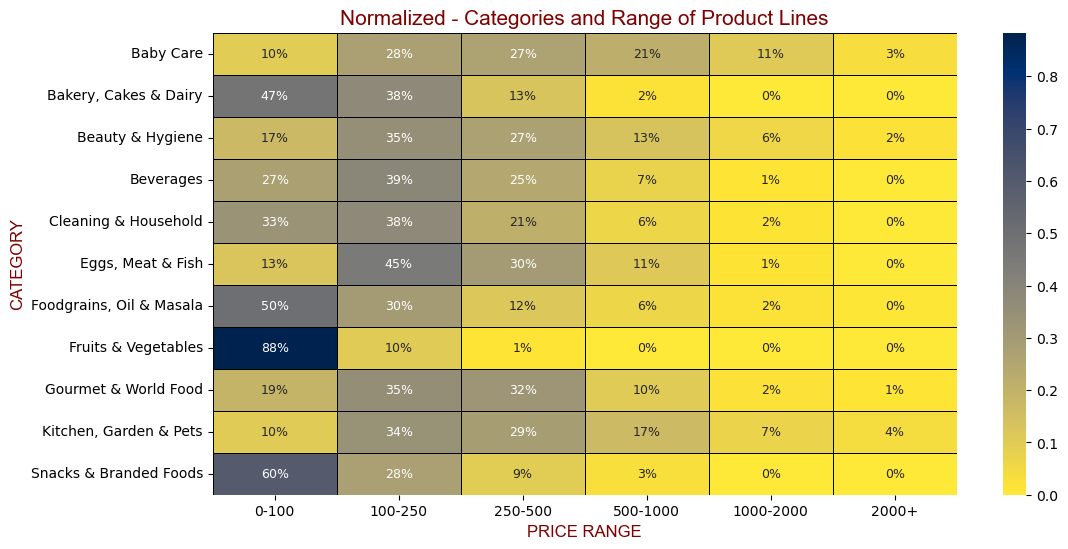

In [155]:
plt.figure(figsize = (12,6))

ax1 = sns.heatmap(heatmap_norm, annot = True, fmt = '.0%', cmap = 'cividis_r', linewidths = 0.5,  annot_kws={'size':9}, linecolor = 'black')

ax1.set_xlabel('PRICE RANGE',font = 'Arial', fontsize = 12, color = 'maroon')
ax1.set_ylabel('CATEGORY',font = 'Arial', fontsize = 12, color = 'maroon')
ax1.set_title('Normalized - Categories and Range of Product Lines',font = 'Arial', fontsize = 15, color = 'maroon')

plt.show()

### 5.5 Do costlier products have better ratings

In [157]:

df_pdts = df[['product','sale_price_categories','rating','sale_price']]

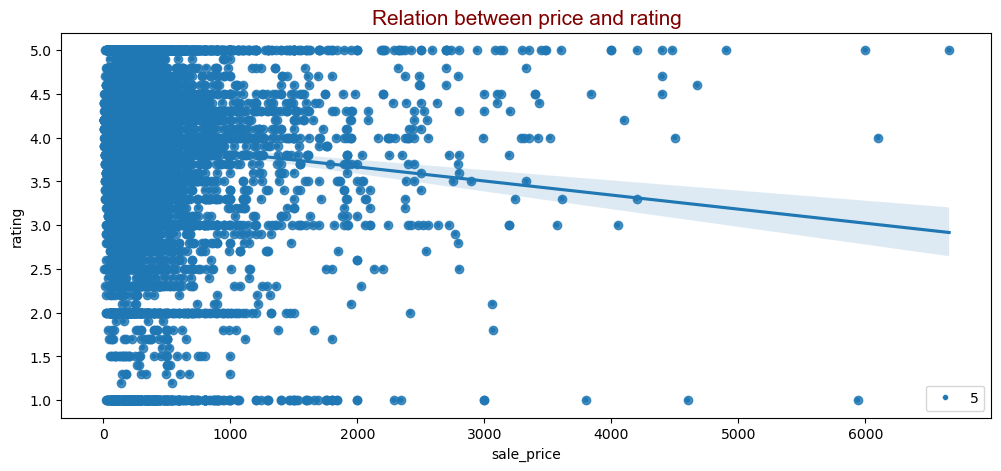

In [158]:

# scatter + regression line
fig, ax1 = plt.subplots(figsize = (12,5))

ax1 = sns.scatterplot(df_pdts, x = 'sale_price', y = 'rating', size = 5)
ax1 = sns.regplot(df_pdts,x = 'sale_price', y = 'rating') #, x_bins =30 )

ax1.set_title('Relation between price and rating', font = 'Arial', fontsize = 15, color = 'maroon')

plt.show()


##### Observation: 
The above plot reveals that Customers **Do not equate** high price to high quality. 
If any, they seem to have lesser liking for high priced pdts

*Note this is **not** a statistical observation. 

### 5.6 Brands & Sub-Categories that are overpriced

In [160]:
# Brands

df_brand = df.groupby('brand', as_index = False).agg(mean_rating = ('rating','mean'), total_profit = ('profit','sum'))

In [171]:
# overpriced = profit > 500 and rating less than or equal to 3

# Top 20 overpriced Brands
df_brand.query( "mean_rating <= 3 and total_profit >= 500").nlargest(20,'total_profit').sort_values('mean_rating').reset_index().drop(columns='index')



,brand,mean_rating,total_profit
0,GoYNG,1.000000,2660
1,Ferrari,1.666667,2846
2,Greenchef,2.000000,2330
3,Crompton,2.475000,1396
4,Beverly Hills Polo Club,2.500000,2850
5,Bronson Professional,2.550000,2055
6,UCOOK,2.675000,3547
7,Nova,2.747619,22705
8,Maryaj,2.750000,10690
9,Chicnutrix,2.750000,2652


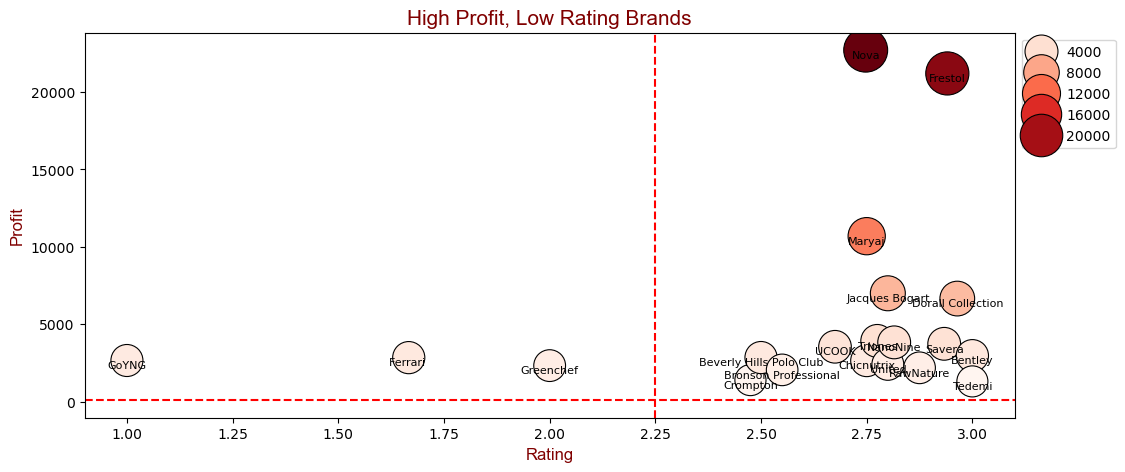

In [170]:
# Overprice Brands 

fig, ax1 = plt.subplots( figsize = (12,5))

df_scat1 = df_brand[(df_brand['mean_rating'] <= 3) & (df_brand['total_profit'] >= 500)].nsmallest(30,'mean_rating').nlargest(20,'total_profit').sort_values('mean_rating').reset_index().drop(columns='index')


ax1 = sns.scatterplot(data = df_scat1, x = 'mean_rating', y = 'total_profit', size = 'total_profit', sizes = (500,1000),
                      hue = 'total_profit', palette = 'Reds', edgecolor = 'black', legend = True, linewidth = 0.8,
                     marker = 'o')

for i in range(len(df_scat1)):
    ax1.text(df_scat1['mean_rating'][i], df_scat1['total_profit'][i], df_scat1['brand'][i],
            va = 'top', ha = 'center', fontsize = 8) 


plt.axvline(x=2.25, linestyle='--', color='red')   # low rating line
plt.axhline(y=100, linestyle='--', color='red')   # high profit line


ax1.set_title('High Profit, Low Rating Brands', font = 'Arial', fontsize = 15, color = 'maroon')

ax1.set_ylabel('Profit',font = 'Arial', fontsize = 12, color = 'maroon')
ax1.set_xlabel('Rating',font = 'Arial', fontsize = 12, color = 'maroon')

plt.legend(bbox_to_anchor= (1,1), loc = 2)

plt.show()


In [172]:
# Subcategories

df_subcat = df.groupby('sub_category').agg(mean_rating = ('rating','mean'), 
                                           total_profit = ('profit','sum'), pdt_cnt = ('product','count')).reset_index()

In [173]:
# Overpriced subcategories - TOP 10

df_subcat[(df_subcat['mean_rating'] <= 3.9) & (df_subcat['total_profit'] >= 150)].nsmallest(30,'mean_rating').nlargest(10,'total_profit').sort_values('mean_rating').reset_index().drop(columns='index')



,sub_category,mean_rating,total_profit,pdt_cnt
0,Steel Utensils,3.543019,96509,353
1,Cookware & Non Stick,3.567925,122604,354
2,Fragrances & Deos,3.672887,243006,1000
3,Bins & Bathroom Ware,3.697712,23462,392
4,Storage & Accessories,3.714719,130170,1015
5,Kitchen Accessories,3.732046,27066,330
6,Health & Medicine,3.740898,19345,1133
7,Appliances & Electricals,3.752419,22345,138
8,Crockery & Cutlery,3.813672,105263,890
9,Drinks & Beverages,3.816250,27790,736


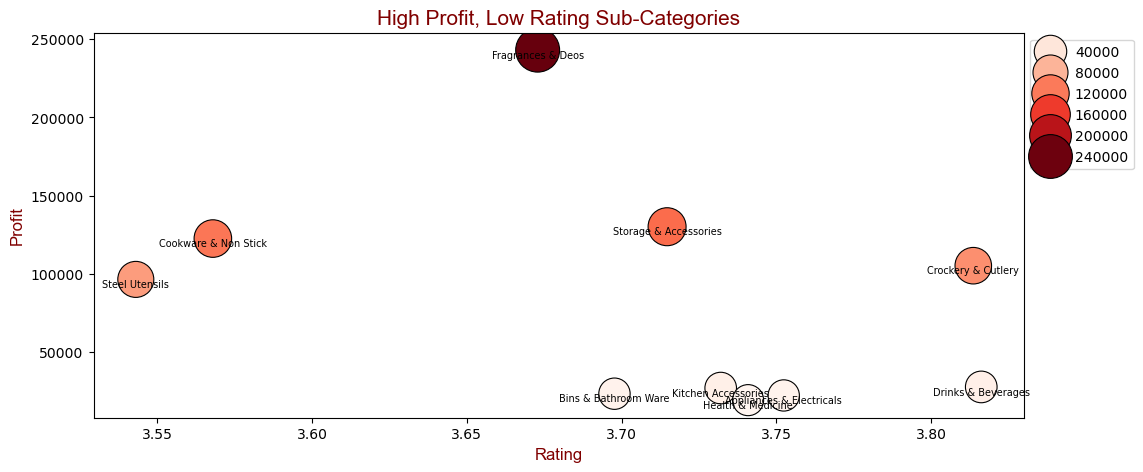

In [169]:
## Overpriced Sub-Categories

fig, ax1 = plt.subplots( figsize = (12,5))

df_scat2 = df_subcat[(df_subcat['mean_rating'] <= 3.9) & (df_subcat['total_profit'] >= 150)].nsmallest(30,'mean_rating').nlargest(10,'total_profit').sort_values('mean_rating').reset_index().drop(columns='index')


ax1 = sns.scatterplot(data = df_scat2, x = 'mean_rating', y = 'total_profit', size = 'total_profit', sizes = (500,1000),
                      hue = 'total_profit', palette = 'Reds', edgecolor = 'black', legend = True, linewidth = 0.8,
                     marker = 'o')

for i in range(len(df_scat2)):
    ax1.text(df_scat2['mean_rating'][i], df_scat2['total_profit'][i], df_scat2['sub_category'][i],
            va = 'top', ha = 'center', fontsize = 7) 


ax1.set_title('High Profit, Low Rating Sub-Categories', font = 'Arial', fontsize = 15, color = 'maroon')

ax1.set_ylabel('Profit',font = 'Arial', fontsize = 12, color = 'maroon')
ax1.set_xlabel('Rating',font = 'Arial', fontsize = 12, color = 'maroon')

plt.legend(bbox_to_anchor= (1,1), loc = 2)

plt.show()

##### Observation:

Top 3 Overpriced Brands: 
1. GOYNG
2. Ferrari
3. Greenchef

Top 3 Overpriced Sub-Categories:
1. Steel Utensils
2. Cookware & Non stick
3. Fragrances & Deos

### 5.7 Sub-categories that offer best value for money

In [174]:
# Value for money = less price more satisfaction

df['valuePerRupee'] = (df['rating']/df['sale_price']).round(3)


In [175]:
df_value = df.groupby('sub_category').agg(mean_rating = ('rating','mean'), total_profit = ('profit','sum'), 
                                         mean_value = ('valuePerRupee','mean'), total_pdts = ('product','count')).dropna()

In [176]:
df_value.sort_values(by = ['mean_value','mean_rating','total_profit'], ascending = [False, False, False]).nlargest(10,'mean_value').reset_index()[['sub_category','mean_value','mean_rating']]



,sub_category,mean_value,mean_rating
0,Biscuits & Cookies,0.142542,4.168953
1,Cakes & Pastries,0.134340,3.765049
2,Snacks & Namkeen,0.105416,3.948190
3,Chocolates & Candies,0.098919,4.117054
4,Gourmet Breads,0.094300,4.040000
5,"Noodle, Pasta, Vermicelli",0.089971,4.127451
6,Water,0.083250,4.175000
7,Masalas & Spices,0.082952,4.115475
8,Energy & Soft Drinks,0.072775,4.177528
9,Ready To Cook & Eat,0.068159,3.908423


In [177]:
df_value_scat = df_value.dropna()

In [178]:
df_value_scat = df_value_scat.sort_values(by = ['mean_value','mean_rating','total_profit'], ascending = [False, False, False]).nlargest(10,'mean_value').reset_index()[['sub_category','mean_value','mean_rating']]


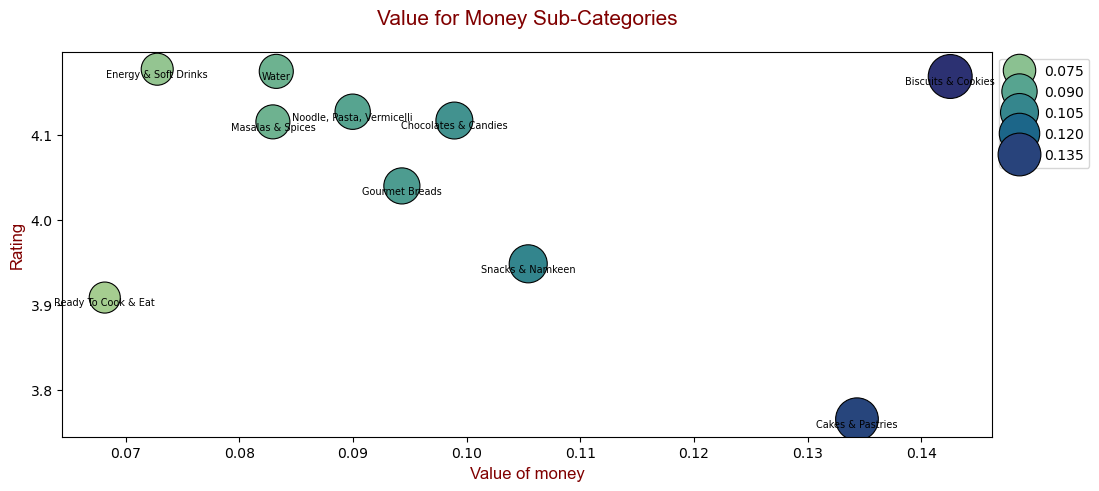

In [184]:
# Best value of money Sub Categories

fig, ax1 = plt.subplots( figsize = (12,5))


ax1 = sns.scatterplot(data = df_value_scat, x = 'mean_value', y = 'mean_rating', size = 'mean_value', sizes = (500,1000),
                      hue = 'mean_value', palette = 'crest', edgecolor = 'black', legend = True, linewidth = 0.8,
                     marker = 'o')

for i in range(len(df_value_scat)):
    ax1.text(df_value_scat['mean_value'][i], df_value_scat['mean_rating'][i], df_value_scat['sub_category'][i],
            va = 'top', ha = 'center', fontsize = 7) 

ax1.set_title('Value for Money Sub-Categories', font = 'Arial', fontsize = 15, color = 'maroon', y = 1.05)

ax1.set_ylabel('Rating',font = 'Arial', fontsize = 12, color = 'maroon')
ax1.set_xlabel('Value of money',font = 'Arial', fontsize = 12, color = 'maroon')

plt.legend(bbox_to_anchor= (1,1), loc = 2)

plt.show()

##### Observation

Best Value for Money: 
Pdts that cost less but provide higher customer experience.
1. Biscuits & Cookies
2. Cakes & Pasteries
3. Snacks and Namkeen
   

## 6. Summary

1. Chocolates and Candies rank the highest in customer satisfaction
2. High-priced products tend to receive low ratings overall
3. Steel utensils and cookware including non-stick are overpriced
4. Kitchen, Garden & pets and Beauty and Hygiene Categories are overpriced
5. Dry fruits generate massive profits but have below average ratings. 